In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("../data/parkinsons.csv")




Shape: (195, 24)


## Dataset Overview

- Total Samples: 195  
- Total Features: 24  
- Numerical Features: 22  
- Categorical Feature: 1 (`name`)  
- Target Variable: `status`  

The dataset contains no missing values and is fully structured.

---

## Target Variable Analysis

- `status = 1` → Parkinson’s Disease  
- `status = 0` → Healthy  

- Mean value: 0.75  

This indicates that ~75% of the samples belong to Parkinson’s patients, showing a class imbalance.

---

## Feature Categories

### 1. Pitch Features
- `MDVP:Fo(Hz)`, `MDVP:Fhi(Hz)`, `MDVP:Flo(Hz)`  
These represent the fundamental frequency of the voice.

---

### 2. Jitter (Frequency Variation)
- `MDVP:Jitter(%)`, `MDVP:RAP`, `MDVP:PPQ`, `Jitter:DDP`  
These measure variations in frequency.

---

### 3. Shimmer (Amplitude Variation)
- `MDVP:Shimmer`, `Shimmer:APQ3`, `Shimmer:APQ5`, `MDVP:APQ`, `Shimmer:DDA`  
These represent variations in signal amplitude.

---

### 4. Noise Measures
- `NHR` (Noise-to-Harmonics Ratio)  
- `HNR` (Harmonics-to-Noise Ratio)  

These indicate the level of noise in the voice signal.

---

### 5. Nonlinear Features
- `RPDE`, `DFA`, `D2`, `PPE`  

These capture complexity and irregular patterns in voice signals.

---

## Statistical Observations

- Features show wide ranges (e.g., `MDVP:Fhi(Hz)` from 102 to 592)
- Presence of outliers is likely
- Feature scaling is required before modeling

---

## Key Issues

- Class imbalance (majority class = Parkinson’s)
- Different feature scales
- Potential outliers

---

## Conclusion

The dataset is clean and suitable for classification tasks.  
Voice-based features show strong potential for detecting Parkinson’s Disease using machine learning models.

In [7]:
print("Shape:", df.shape)

Shape: (195, 24)


In [4]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [6]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [8]:
df.isnull().sum()

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

## Data Cleaning: Removing Irrelevant Column

The dataset contains a column named `name`, which represents a unique identifier for each audio sample.

This column does not contribute to the prediction task and may introduce unnecessary noise into the model.

Therefore, it is removed before further analysis and model training.



In [9]:
df = df.drop(columns=["name"])

## Target Variable Analysis

A count plot was used to examine the distribution of the target variable (`status`).

- `status = 1` → Parkinson’s Disease  
- `status = 0` → Healthy  

### Observations

- The dataset is **imbalanced**
- Approximately **75% of samples are Parkinson’s patients**
- Remaining **25% are healthy individuals**

### Interpretation

The higher number of Parkinson’s cases indicates a class imbalance, which may bias the model toward predicting the majority class.

### Recommendation

Techniques such as resampling (oversampling/undersampling) or using evaluation metrics like F1-score should be considered to handle imbalance.

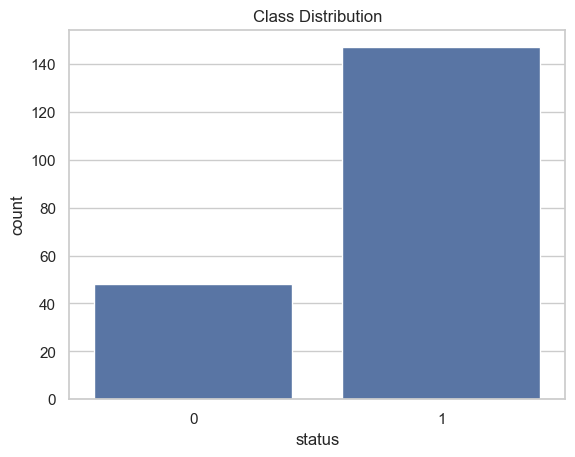

In [11]:
sns.countplot(x="status", data=df)
plt.title("Class Distribution")
plt.show()

In [12]:
print(df["status"].value_counts(normalize=True))

status
1    0.753846
0    0.246154
Name: proportion, dtype: float64


## Correlation Analysis

Correlation values range from -1 to +1 and indicate the strength and direction of the relationship between variables.

### Key Interpretations

- **Positive Correlation (+1):**  
  When one feature increases, the other also increases.  
  Example: `MDVP:Jitter(%)` and `MDVP:RAP` show very high correlation (~0.99), indicating redundant information.

- **Negative Correlation (-1):**  
  When one feature increases, the other decreases.  
  Example: `HNR` and `NHR` are negatively correlated, meaning higher noise reduces voice clarity.

- **No Correlation (0):**  
  No meaningful relationship between variables.

---

### Insights for This Project

- **Correlation with Target (`status`):**  
  Features like `PPE`, `spread1`, and `MDVP:Shimmer` show relatively strong correlation with the target, making them important for prediction.

- **Multicollinearity:**  
  Several features (especially jitter-related) are highly correlated (>0.9), indicating redundancy.  
  Reducing such features can simplify the model without losing performance.

- **HNR vs Status:**  
  `HNR` tends to have a negative relationship with the target, suggesting that lower voice clarity is associated with Parkinson’s disease.

---

### Conclusion

Correlation analysis helps identify:
- Important predictive features  
- Redundant variables  
- Underlying relationships in voice data  

This step is critical for effective feature selection and model performance.

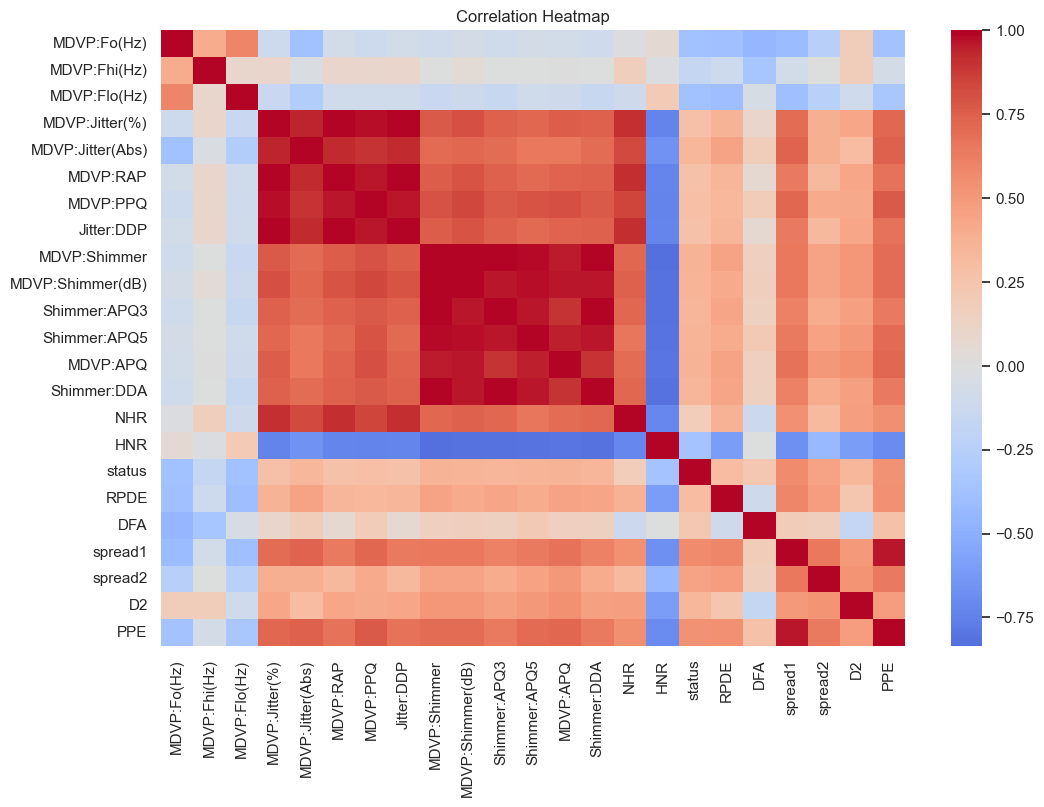

In [13]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Feature Importance using Correlation

Correlation with the target variable (`status`) was computed to identify important features.

### Method

```python
corr_target = corr["status"].abs().sort_values(ascending=False)

In [14]:
corr_target = corr["status"].abs().sort_values(ascending=False)
print(corr_target.head(10))

status          1.000000
spread1         0.564838
PPE             0.531039
spread2         0.454842
MDVP:Fo(Hz)     0.383535
MDVP:Flo(Hz)    0.380200
MDVP:Shimmer    0.367430
MDVP:APQ        0.364316
HNR             0.361515
Shimmer:APQ5    0.351148
Name: status, dtype: float64


## Feature Distribution Analysis (Class-wise)

To understand how important features behave across Parkinson’s (1) and Healthy (0) classes, Kernel Density Estimation (KDE) plots were used.

### Selected Features:
- MDVP:Fo(Hz) → Fundamental frequency (pitch)
- MDVP:Jitter(%) → Frequency variation (instability)
- MDVP:Shimmer → Amplitude variation (voice weakness)
- HNR → Harmonics-to-noise ratio (voice clarity)

### Objective:
- Analyze how feature distributions differ between classes
- Identify features with clear separation
- Support feature selection for model training

### Insight:
- Features with clear separation between classes are strong predictors
- Overlapping distributions indicate weaker predictive power

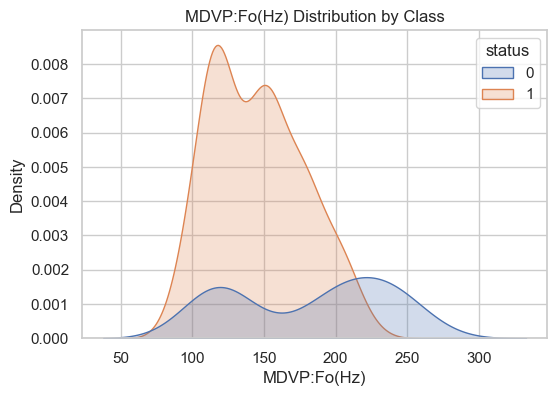

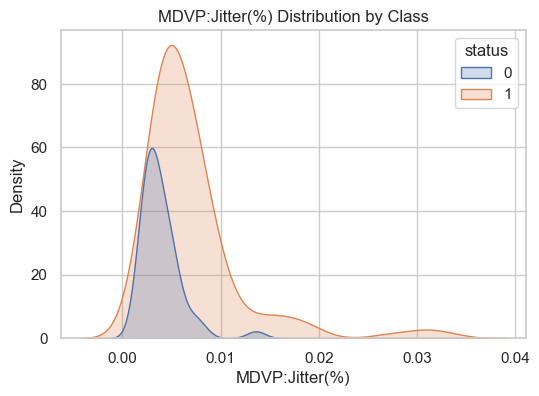

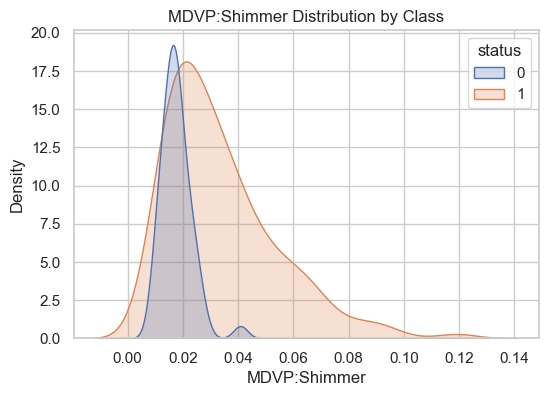

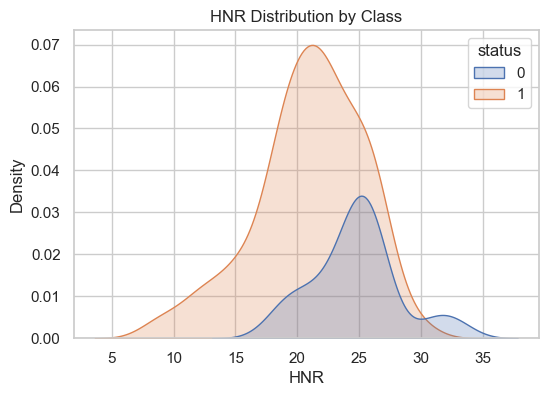

In [15]:
features = ["MDVP:Fo(Hz)", "MDVP:Jitter(%)", "MDVP:Shimmer", "HNR"]

for col in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="status", fill=True)
    plt.title(f"{col} Distribution by Class")
    plt.show()

## Boxplot Analysis (Feature vs Target)

Class-wise boxplots were used to compare feature distributions between Parkinson’s (1) and Healthy (0) subjects.

This helps in:
- Identifying discriminative features (clear separation between classes)  
- Detecting outliers that may impact model performance  
- Understanding data variability across classes  

Features with distinct separation were considered more useful for model training.

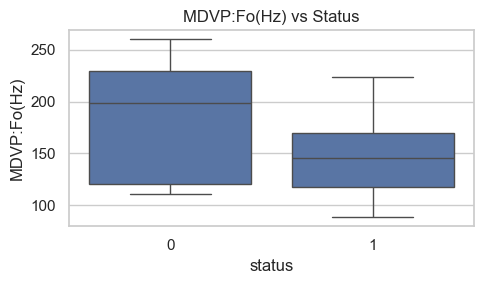

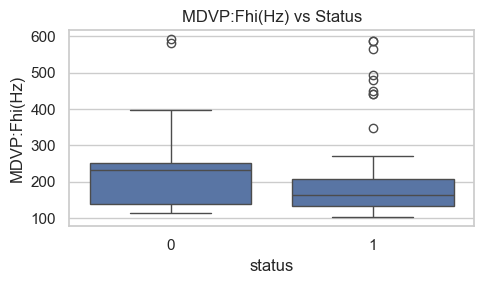

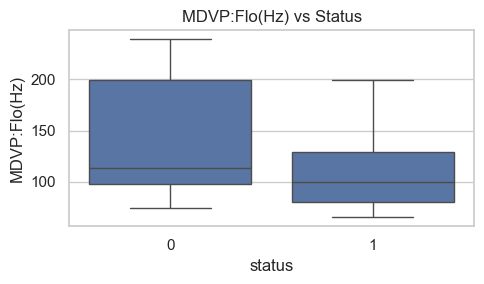

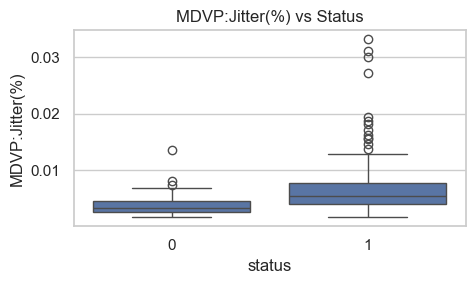

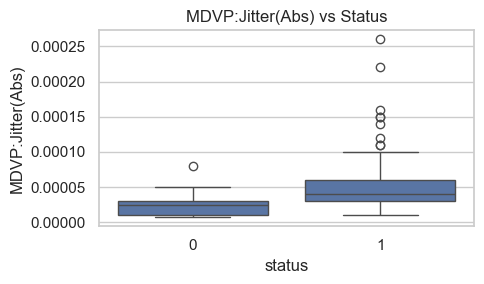

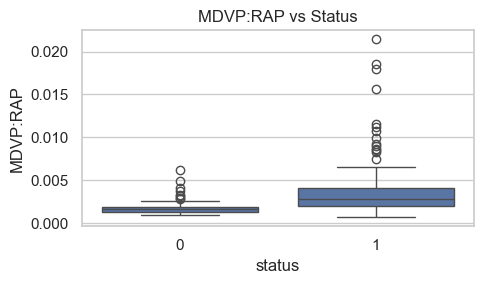

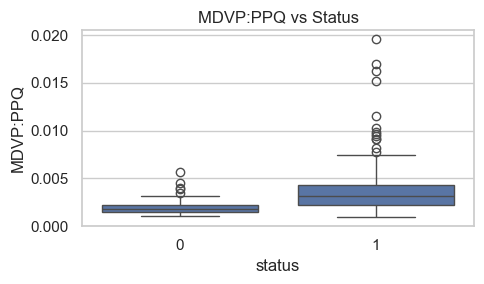

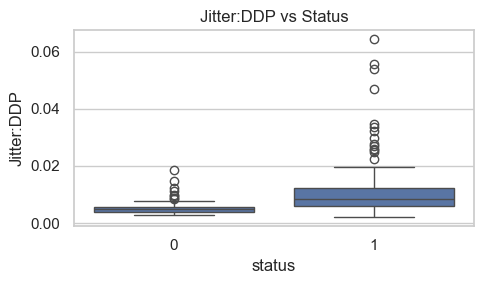

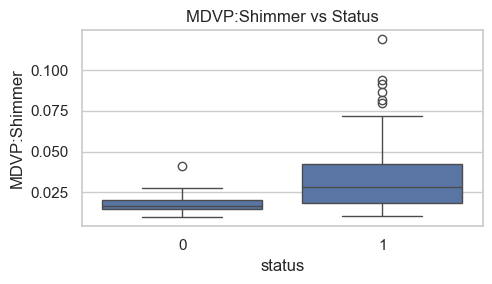

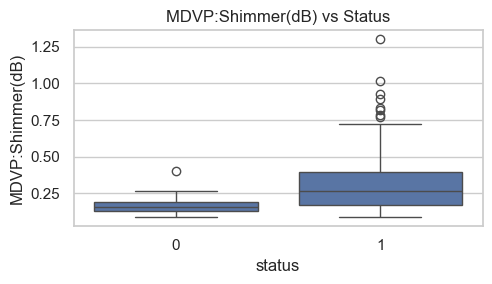

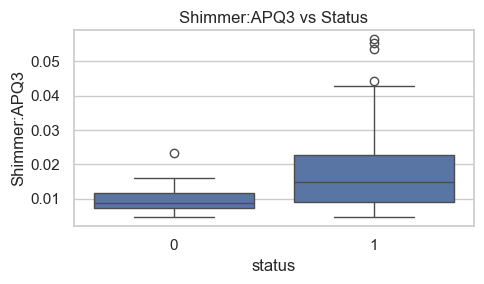

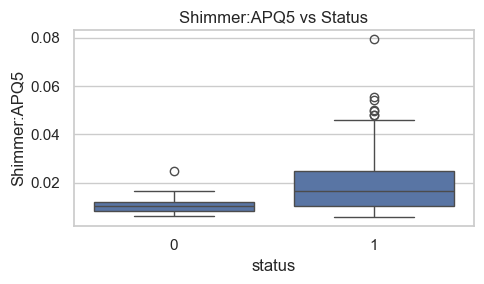

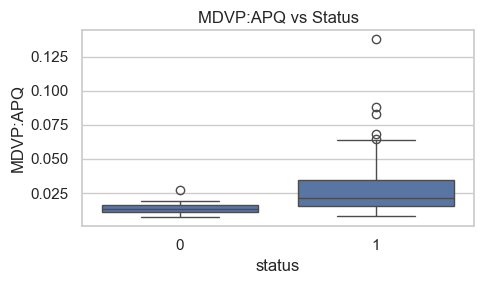

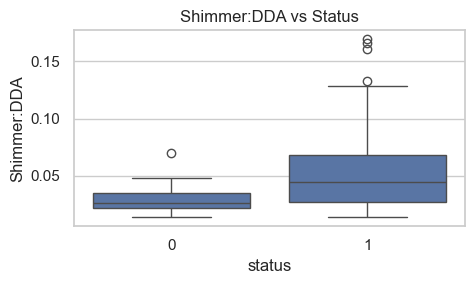

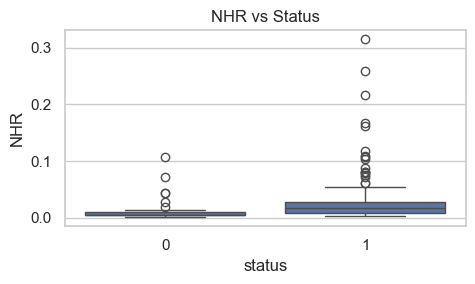

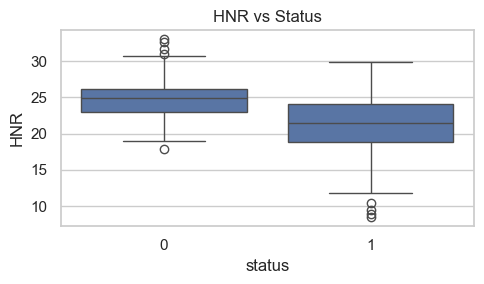

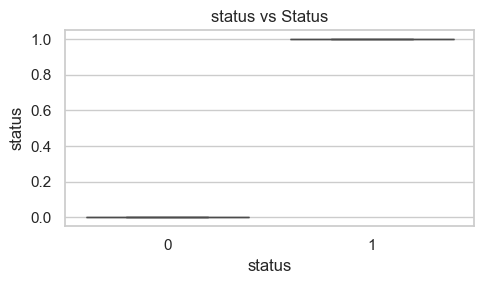

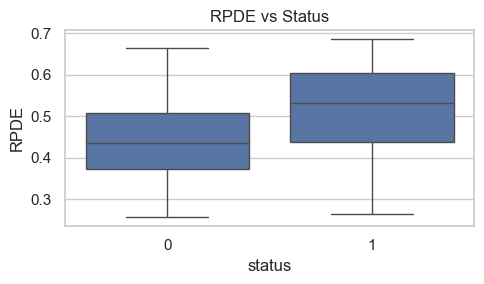

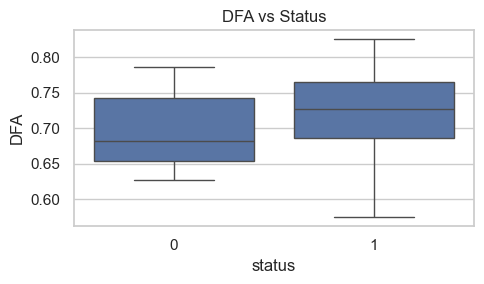

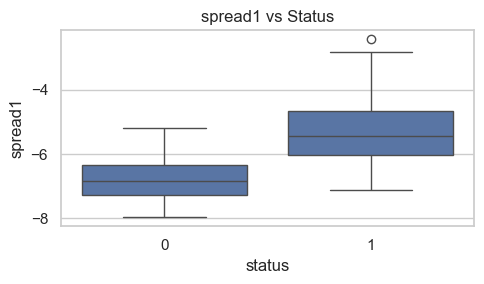

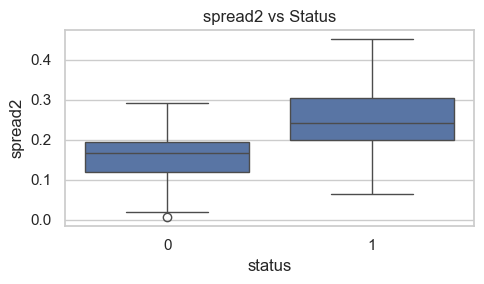

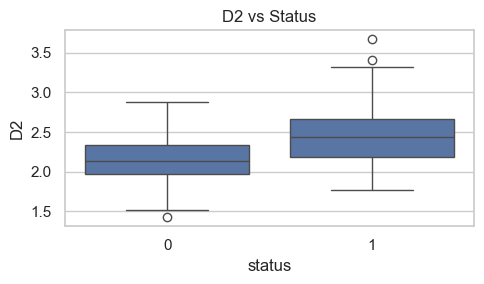

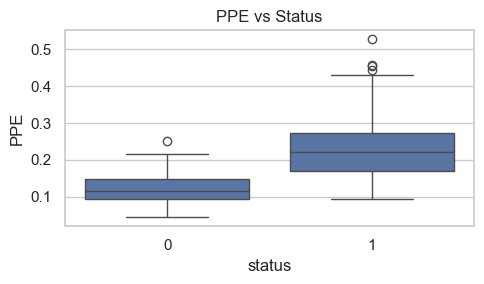

In [17]:
features = df.select_dtypes(include=["float64", "int64"]).columns

for col in features:
    plt.figure(figsize=(5,3))
    
    sns.boxplot(x="status", y=col, data=df)
    
    plt.title(f"{col} vs Status")
    plt.tight_layout()
    plt.show()